In [8]:
from dm_control import suite
from dm_control import mjcf
from dm_control import mujoco
from dm_control import viewer
from dm_control.suite.wrappers import pixels

import numpy as np
import PIL.Image

from dm_control.suite import common


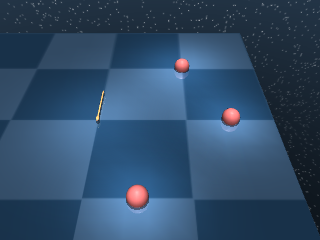

In [6]:
path = '/Users/reecekeller/Documents/neuroagents/zebrafish_agent/mujoco_bodies/swimmer5.xml'
with open(path, 'r') as file:
    xml_string = file.read()
physics = mujoco.Physics.from_xml_string(xml_string)
pixels = physics.render()
PIL.Image.fromarray(pixels)


In [2]:
ALL_TASKS = suite._get_tasks(tag=None)
ALL_TASKS

NameError: name 'suite' is not defined

In [4]:
# Load an environment from the Control Suite.

# write own suite.load
env = suite.load(domain_name="swimmer", task_name="swimmer6")
# Launch the viewer application.
action_spec = env.action_spec()

# Define a uniform random policy.
def random_policy(time_step):
  del time_step  # Unused.
  return np.random.uniform(low=action_spec.minimum,
                           high=action_spec.maximum,
                           size=action_spec.shape)

# Launch the viewer application.
viewer.launch(env, policy=random_policy)

In [1]:
import dm_control.suite.swimmer as swimmer


In [4]:
model_string, assets = swimmer.get_model_and_assets(4)
physics = swimmer.Physics.from_xml_string(model_string, assets=assets)

In [9]:
env = suite.load("swimmer", "swimmer6")
env = pixels.Wrapper(env, pixels_only=False)

In [10]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Load the environment
env = suite.load(domain_name="swimmer", task_name="swimmer6")

# Define a random policy
def random_policy(time_step):
    return np.random.uniform(low=-1.0, high=1.0, size=env.action_spec().shape)

# Run the environment
time_step = env.reset()
frames = []
viewer = env.physics.render(camera_id=0)
while not time_step.last():
    action = random_policy(time_step)
    time_step = env.step(action)
    frame = viewer.read_pixels(width=256, height=256, depth=False)
    frames.append(frame)

# Display the frames as a video
fig, ax = plt.subplots()
im = ax.imshow(frames[0])
def update(i):
    im.set_data(frames[i])
    return [im]
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=50, blit=True)
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'read_pixels'

: 